In [1]:
import matplotlib.pyplot as plt 
from astropy.io import fits 
import numpy as np 

In [7]:
data_list = []

for i in range(1, 6):
    filename = f"M13_000{i}.fits"

    with fits.open(filename) as hdul:
        data = hdul[0].data
        data_list.append(data)

print(len(data_list))

5


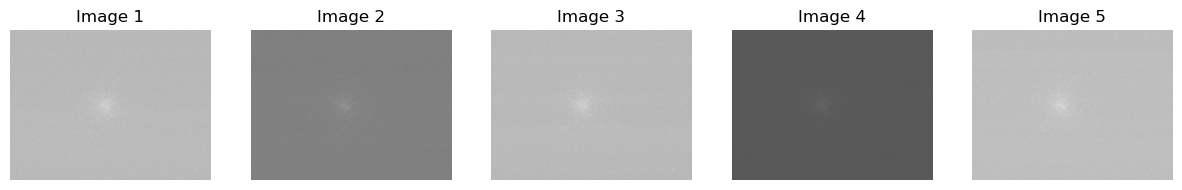

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].imshow(data_list[i], cmap="gray", origin="lower")
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")

plt.show()
    

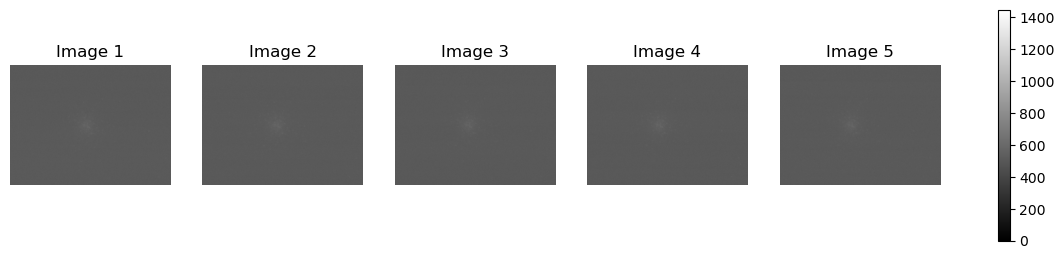

In [15]:
vmin = min(np.min(data) for data in data_list)
vmax = max(np.max(data) for data in data_list)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    im = axes[i].imshow(data_list[i], cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")

fig.colorbar(im, ax=axes.ravel().tolist())
plt.show()

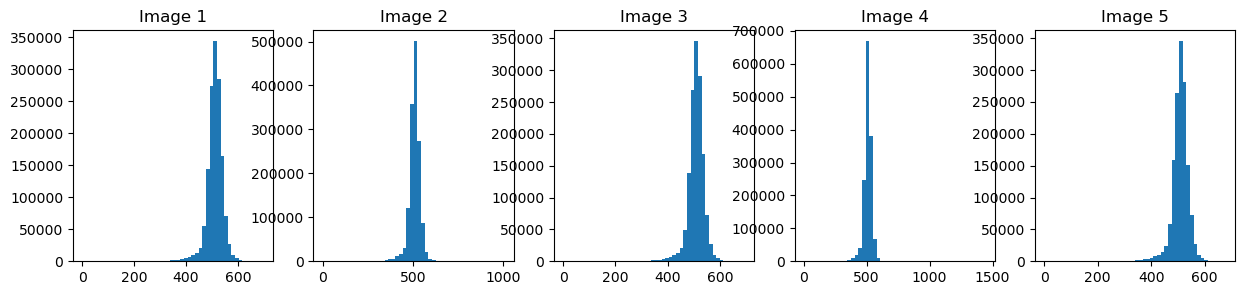

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].hist(data_list[i].ravel(), bins=50)
    axes[i].set_title(f"Image {i+1}")

plt.show()

In [17]:
#(a) x-axis--> pixel intensity value , y-axis--> number of pixels 
#(b) bins=50 divides the data into 50 intervals 
#(c) Most of the data centered for pixel intensity are at low pixel intensities
#(d) The data is tightly clustered, with a long tail of higher values 
#(e) The median/mean pixel intensity for each image:
for i in range(5):
    data = data_list[i].ravel()
    print(f"Image {i+1}: mean={np.mean(data):.2f}, median={np.median(data):.2f}")

Image 1: mean=510.47, median=512.00
Image 2: mean=509.75, median=511.00
Image 3: mean=508.05, median=510.00
Image 4: mean=507.91, median=509.00
Image 5: mean=508.79, median=510.00


In [18]:
combined_image = np.median(data_list, axis=0)

In [19]:
print(np.median(combined_image))

510.0


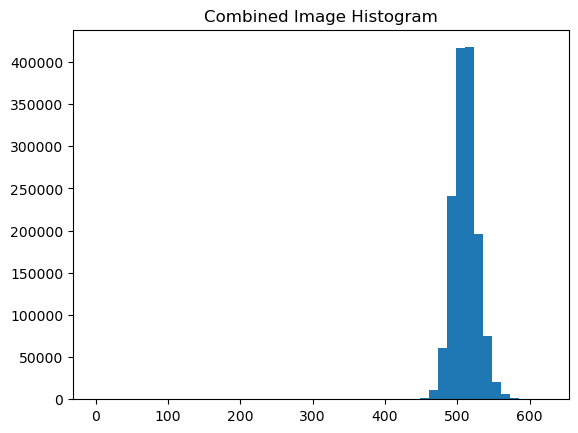

In [20]:
plt.hist(combined_image.ravel(), bins=50)
plt.title("Combined Image Histogram")
plt.show()

In [21]:
vmin = np.percentile(combined_image, 5)
vmax = np.percentile(combined_image, 95)

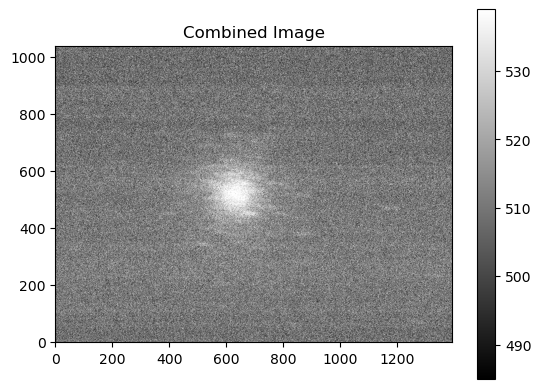

In [22]:
plt.imshow(combined_image, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined Image")
plt.show()

In [23]:
fits.writeto("combined.fits", combined_image, overwrite=True)

In [24]:
vmin = np.percentile(combined_image, 5)
vmax = np.percentile(combined_image, 95)

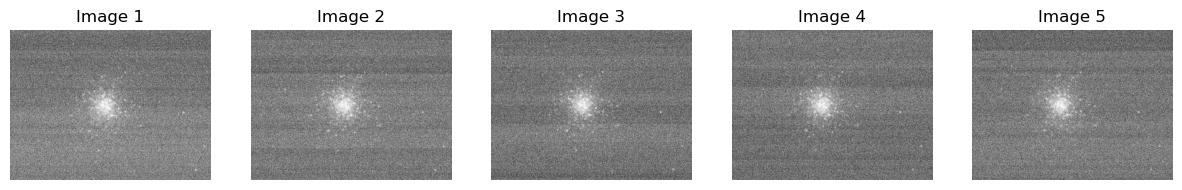

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].imshow(data_list[i], cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")

plt.show()